# Prelim visualizations

Three figures for the preliminary report, saved to `results/figures/` as PNG.

1. Complexity signals per detector (% of examples)
2. Complexity co-occurrence (how many detectors fire per example)
3. Length distribution: source vs target word count

Reads `results/complexity_prelim.csv`, which has columns: `text`, `has_numerical`,
`has_warning`, `is_syntactically_complex`, `has_umls_jargon`, `complexity_score`.
Each row is one training abstract. The target text for plot 3 comes from the
loader, since it is not in the complexity CSV.

Run from the repo root so the relative paths line up.

In [2]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 3.4 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.2 MB 2.6 MB/s eta 0:00:03
   -------- ------------------------------- 1.8/8.2 MB 3.0 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.2 MB 3.1 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.2 MB 3.5 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.2 MB 3.3 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.2 MB 3.3 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.2 MB 3.4 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.2 MB 3.4 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 3.4 MB/s eta 0:00:01
   ----------------------------------- --

In [3]:
import os
os.chdir(os.path.dirname(os.path.abspath('__file__')) + '/..')  
# sets working dir to project root regardless of where notebook runs
import pandas as pd
import matplotlib.pyplot as plt


CSV = "results/complexity_prelim.csv"
OUT = "results/figures"
os.makedirs(OUT, exist_ok=True)

# display name -> column in complexity_prelim.csv (4 detectors; NER is not in this CSV)
DETECTORS = {
    "UMLS jargon": "has_umls_jargon",
    "Syntactic": "is_syntactically_complex",
    "Numerical risk": "has_numerical",
    "Warning cue": "has_warning",
}
SCORE_COL = "complexity_score"   # already the count of detectors firing
SOURCE_TEXT_COL = "text"

df = pd.read_csv(CSV)
print("rows:", len(df))
print("columns:", list(df.columns))

FileNotFoundError: [Errno 2] No such file or directory: 'results/complexity_prelim.csv'

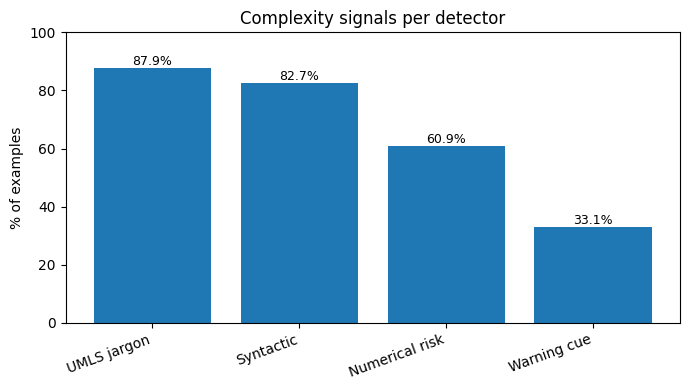

{'UMLS jargon': 87.9, 'Syntactic': 82.7, 'Numerical risk': 60.9, 'Warning cue': 33.1}


In [ ]:
# Plot 1: complexity signals per detector
def as_bool(series):
    return series.astype(str).str.lower().isin(["true", "1", "1.0", "yes"])

flags = {name: as_bool(df[col]) for name, col in DETECTORS.items() if col in df.columns}
F = pd.DataFrame(flags)
pct = (F.mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
plt.bar(pct.index, pct.values)
for i, v in enumerate(pct.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)
plt.ylim(0, 100)
plt.ylabel("% of examples")
plt.title("Complexity signals per detector")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{OUT}/complexity_signals.png", dpi=150)
plt.show()
print(pct.round(1).to_dict())

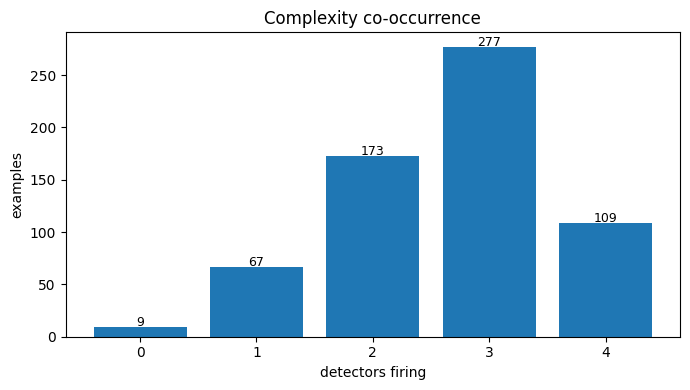

{0: 9, 1: 67, 2: 173, 3: 277, 4: 109}


In [ ]:
# Plot 2: complexity co-occurrence, using the precomputed complexity_score
n_detectors = len(DETECTORS)
counts = df[SCORE_COL].value_counts().sort_index()
counts = counts.reindex(range(0, n_detectors + 1), fill_value=0)

plt.figure(figsize=(7, 4))
plt.bar(counts.index.astype(str), counts.values)
for i, v in enumerate(counts.values):
    plt.text(i, v + 1, str(int(v)), ha="center", fontsize=9)
plt.xlabel("detectors firing")
plt.ylabel("examples")
plt.title("Complexity co-occurrence")
plt.tight_layout()
plt.savefig(f"{OUT}/cooccurrence.png", dpi=150)
plt.show()
print(counts.to_dict())

could not load target from loader, plotting source only: No module named 'src'


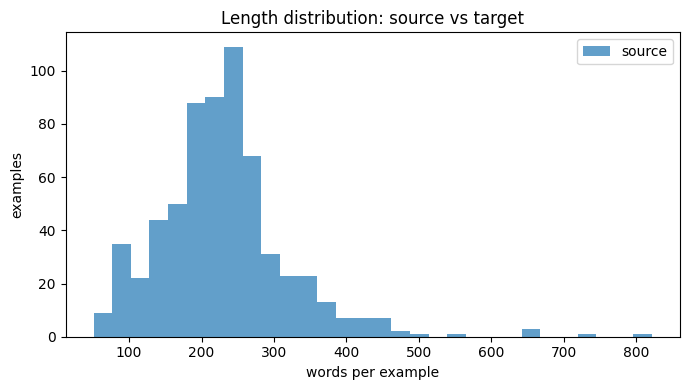

mean source length: 230.3 words


In [ ]:
# Plot 3: length distribution, source vs target word count.
# Source comes from the complexity CSV. Target is not in that CSV, so it comes
# from the loader (train split). Edit TARGET_COL if your CSV names it differently.
src = df[SOURCE_TEXT_COL].astype(str)
src_len = src.str.split().apply(len)

TARGET_COL = "target_text"
tgt_len = None
try:
    from src.data.plaba_loader import load_train
    train = load_train()
    if TARGET_COL in train.columns:
        tgt_len = train[TARGET_COL].astype(str).str.split().apply(len)
    else:
        print("target column not found, columns are:", list(train.columns))
except Exception as e:
    print("could not load target from loader, plotting source only:", e)

plt.figure(figsize=(7, 4))
plt.hist(src_len, bins=30, alpha=0.7, label="source")
if tgt_len is not None:
    plt.hist(tgt_len, bins=30, alpha=0.7, label="target")
plt.xlabel("words per example")
plt.ylabel("examples")
plt.title("Length distribution: source vs target")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT}/length_distribution.png", dpi=150)
plt.show()

print(f"mean source length: {src_len.mean():.1f} words")
if tgt_len is not None:
    print(f"mean target length: {tgt_len.mean():.1f} words")